Import Libararies

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default='svg'


C:\Users\USER\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




This setup gives you:

Pandas → Data manipulation

NumPy → Numerical computation

Matplotlib → Basic plotting

Seaborn → Statistical visualization

Plotly → Interactive visualization

Plotly IO → Rendering control

In [6]:
#!pip install plotly


In [7]:
#importing the DATASET
raw_df=pd.read_csv('Zomato_Mumbai_Dataset.csv',delimiter='|')
#👉 Delimiter = column boundary marker

In [8]:
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Mumbai,First International Financial Centre-- Bandra ...,https://www.zomato.com/mumbai/hitchki-bandra-k...,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mumbai,Mahim,https://www.zomato.com/mumbai/baba-falooda-mah...,1,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/butterfly-high-b...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/bkc-dive-bandra-...,1,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995


Getting the basic information about the datasset

In [9]:
raw_df.shape

(15081, 12)

In [10]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15081 entries, 0 to 15080
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   NAME             15081 non-null  object
 1   PRICE            15080 non-null  object
 2   CUSINE_CATEGORY  15079 non-null  object
 3   CITY             15080 non-null  object
 4   REGION           15080 non-null  object
 5   URL              15080 non-null  object
 6   PAGE NO          15080 non-null  object
 7   CUSINE TYPE      15080 non-null  object
 8   TIMING           15015 non-null  object
 9   RATING_TYPE      14070 non-null  object
 10  RATING           15080 non-null  object
 11  VOTES            15080 non-null  object
dtypes: object(12)
memory usage: 1.4+ MB


In [11]:
raw_df.describe(include='all')


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
count,15081,15080,15079,15080,15080,15080,15080,15080,15015,14070,15080,15080
unique,12720,67,3183,2,241,13823,944,23,2551,31,35,1124
top,NAME,400,CUSINE_CATEGORY,Mumbai,REGION,URL,PAGE NO,Quick Bites,11am to 11pm(Mon-Sun),Average,-,-
freq,942,2042,942,14138,942,942,942,5262,1192,5112,2360,2360


Cleaning The Dataset

In [12]:
#Removing the redundunt rows of Data

In [13]:
#checking redundunt rows of data      redundunt---> having too much of information
#                                                    which is lead to wasted resource 

wrong_data=raw_df['PAGE NO']=="PAGE NO"
raw_df[wrong_data]
#in the dataset the rows were repated like this 
#NAME	PRICE	CUSINE_CATEGORY	CITY	REGION	URL	PAGE NO	CUSINE TYPE	TIMING	RATING_TYPE	RATING	VOTES
#because the data is retriving from the websites soo they have some constrains like 15 rows after it should be go to the next 
#page so again in that next page they assagined the name soo when we get the full dataset it also repated soo we removing again


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
31,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
47,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
63,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
79,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
...,...,...,...,...,...,...,...,...,...,...,...,...
15000,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15016,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15032,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15048,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [14]:
## Performing Negation of the wrong dataset and then storing the correct data back in the raw_df DataFrame
## This permamnently remove the wrong data from the original dataframe

raw_df=raw_df[~wrong_data]# changes the false to true value 
#in that condition true means those are useless data rows soo we need to remove them 
#sooo we changes that true to false withe the help of negation soo that false will be discard 
backup_df = raw_df.copy()


In [15]:
# Dropping columns which are not required for further analysis
raw_df.drop(['URL','PAGE NO',"CITY"],axis=1,inplace=True)

In [16]:
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995


In [17]:
# b) removing the NULL Records

In [18]:
#Checking for Null records
raw_df.isnull().sum()

NAME                  0
PRICE                 1
CUSINE_CATEGORY       2
REGION                1
CUSINE TYPE           1
TIMING               66
RATING_TYPE        1011
RATING                1
VOTES                 1
dtype: int64

In [19]:
#checking for a null row
raw_df[raw_df['PRICE'].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15080,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Dropping the above row from the dataset
raw_df=raw_df.drop(labels=15080,axis=0)

In [21]:
#Replacing the other Null Records with NA
raw_df.fillna('NA',inplace=True)

In [22]:
#Confiming all the null records are the coreect
raw_df.isnull().sum()

NAME               0
PRICE              0
CUSINE_CATEGORY    0
REGION             0
CUSINE TYPE        0
TIMING             0
RATING_TYPE        0
RATING             0
VOTES              0
dtype: int64

In [23]:
#c) Converting the Datatypes of numerical columns to numeric datatype

In [24]:
#checking for text values in the column before converting it to numeric datatype
raw_df['RATING'].value_counts()

RATING
-          2360
3.5        1094
3.4        1036
3.6         960
NEW         953
3.3         926
3.7         917
3.2         801
3.8         782
3.1         734
3.0         622
3.9         596
2.9         409
4.0         408
2.8         309
4.1         298
4.2         199
2.7         170
4.3         148
4.4          99
2.6          77
Opening      57
4.5          46
2.5          39
4.6          32
2.4          26
4.7          13
2.3          10
2.1           5
4.8           4
2.2           4
4.9           2
1.8           1
2.0           1
Name: count, dtype: int64

In [25]:
#Replacing the Text values with 0(zero)
raw_df['RATING'].replace(to_replace=['-','NEW','Opening'],value='0',inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11872\634688844.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [26]:
#checking for the text values in the column before converting it to numeric datatype
raw_df['VOTES'].value_counts()

VOTES
-       2360
NEW      953
4        364
5        320
6        288
        ... 
2797       1
1876       1
2092       1
3191       1
3529       1
Name: count, Length: 1123, dtype: int64

In [27]:
raw_df['VOTES'].replace(to_replace=['-','NEW','Opening'],value='0',inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11872\2468739550.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [28]:
raw_df['PRICE'].replace(to_replace=['PRICE'],value='0',inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11872\2992524856.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [29]:
#Changing Datatype of the numerical columns 
raw_df['PRICE']=raw_df['PRICE'].astype('int64')
raw_df['RATING']=raw_df['RATING'].astype('float64')
raw_df['VOTES']=raw_df['VOTES'].astype('int64')

In [30]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14138 entries, 0 to 15079
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             14138 non-null  object 
 1   PRICE            14138 non-null  int64  
 2   CUSINE_CATEGORY  14138 non-null  object 
 3   REGION           14138 non-null  object 
 4   CUSINE TYPE      14138 non-null  object 
 5   TIMING           14138 non-null  object 
 6   RATING_TYPE      14138 non-null  object 
 7   RATING           14138 non-null  float64
 8   VOTES            14138 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.1+ MB


In [31]:
#d) Working with 'Timing' Column

In [32]:
raw_df['TIMING'].value_counts()

TIMING
11am to 11pm(Mon-Sun)                            1192
11am to 12midnight(Mon-Sun)                       632
12noon to 12midnight(Mon-Sun)                     467
11am to 1130pm(Mon-Sun)                           309
10am to 10pm(Mon-Sun)                             267
                                                 ... 
11am to 3pm,430pm to 11pm(Mon-Sun)                  1
1230pm to 330pm,530pm to 1130pm(Mon-Sun)            1
630pm to 1130pm(Mon),11am to 3pm,630pm to ...       1
Closed(Mon),1030am to 330pm,630pm to 11pm...        1
8am to 11am,12noon to 3pm,730pm to 1130pm...        1
Name: count, Length: 2551, dtype: int64

In [33]:
#splitting the column and starting it in temp_df dataframe
temp_df=raw_df['TIMING'].str.split('(',n=1,expand=True)
temp_df

,0,1
0,12noon to 130am,Mon-Sun)
1,2pm to 1am,Mon-Sun)
2,12noon to 1am,Mon-Sun)
3,12noon to 130am,Mon-Sun)
4,1130am to 1am,Mon-Sun)
...,...,...
15075,"8am to 11pm,12midnight to 115am",Mon-Sun)
15076,11am to 230am,Mon-Sun)
15077,11am to 11pm,"Mon,Tue,Wed,Thu,Sun),11am to ..."
15078,9am to 1230AM,Mon-Sun)


In [34]:
#Assigining the columns back to the row_df dataframe
raw_df['TIMING']=temp_df[0]
raw_df['DAYS_OPEN']=temp_df[1]

In [35]:
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun)
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun)
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun)
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun)
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun)


In [36]:
#Removing the bracket character from days columns
raw_df['DAYS_OPEN']=raw_df['DAYS_OPEN'].str.replace(')','',regex=False)
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun


In [37]:
raw_df.isnull().sum()

NAME                 0
PRICE                0
CUSINE_CATEGORY      0
REGION               0
CUSINE TYPE          0
TIMING               0
RATING_TYPE          0
RATING               0
VOTES                0
DAYS_OPEN          160
dtype: int64

In [38]:
raw_df.fillna('NA',inplace=True)

In [39]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14138 entries, 0 to 15079
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             14138 non-null  object 
 1   PRICE            14138 non-null  int64  
 2   CUSINE_CATEGORY  14138 non-null  object 
 3   REGION           14138 non-null  object 
 4   CUSINE TYPE      14138 non-null  object 
 5   TIMING           14138 non-null  object 
 6   RATING_TYPE      14138 non-null  object 
 7   RATING           14138 non-null  float64
 8   VOTES            14138 non-null  int64  
 9   DAYS_OPEN        14138 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 1.2+ MB


In [40]:
#e)Removing the restaurant records whose rating or votes is 0

In [41]:
#finding those restaurant whose has 0 rating or Votes

useless_data=(raw_df['RATING']==0.0) | (raw_df['VOTES']==0) #That’s the element-wise OR operator in Pandas.
raw_df[useless_data]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
32,Hotel Annapoorna Refreshments,400,"Maharashtrian,Mughlai,Chinese",Ghansoli,Quick Bites,1030am to 1230AM,Not rated,0.0,0,Mon-Sun
34,Biryani 9,600,"Biryani,North Indian",Near Andheri East Station,none,11am to 3am,NA,0.0,0,Mon-Sun
36,D Fusion Flavours,350,Chinese,Goregaon East,none,"12noon to 330pm,7pm to 3am",NA,0.0,0,Mon-Sun
39,Nation Tadka,400,"North Indian,South Indian,Chinese,Fast Food",Worli,none,12noon to 1230AM,Not rated,0.0,0,Mon-Sun
83,Link Way Restaurant,500,"North Indian,Chinese",Jogeshwari,Quick Bites,"12noon to 4pm,8pm to 1am",Not rated,0.0,0,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14998,Foodies House,0,Chinese,Goregaon East,none,12noon to 4am,NA,0.0,0,Mon-Sun
14999,Khansama,0,Biryani,Lower Parel,none,12noon to 3am,NA,0.0,0,Mon-Sun
15010,Earth Cafe @ Waterfield,800,"Cafe,Healthy Food,Italian,Pizza,Beverages",Linking Road-- Bandra West,Café,10am to 10pm,NA,0.0,0,"Mon-Thu,10am to 11pm(Fri-Sun"
15023,How About Some Cream,200,Beverages,Mumbai Central,Beverage Shop,12noon to 3am,NA,0.0,0,Mon-Sun


In [42]:
#Performing Negation of the useless dataset and then storing the correct data back in the raw_df dataframe
## This permanently remove the wrong data from the original dataframe 

raw_df=raw_df[~useless_data]

In [43]:
#f) Working on 'RATING_TYPE' Column

In [44]:
#Checking the Unique values in the columns 
raw_df['RATING_TYPE'].value_counts()

RATING_TYPE
Average          5111
Good             4330
Very Good        1137
Excellent          95
Poor               47
Veľmi dobré         6
Skvělá volba        4
Dobrze              4
Bardzo dobrze       3
İyi                 2
Buono               2
Bom                 2
Muito Bom           2
Promedio            2
Dobré               2
Priemer             2
Průměr              2
Ortalama            2
Bueno               2
Excelente           1
Velmi dobré         1
Baik                1
Çok iyi             1
Skvělé              1
Média               1
Sangat Baik         1
Biasa               1
Muy Bueno           1
Media               1
Name: count, dtype: int64

In [45]:
#translating the text into proper English text
raw_df['RATING_TYPE'].replace(to_replace='Excelente',value='Excellent',inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Veľmi dobré','Bardzo dobrze','Muy Bueno','Velmi dobré'],value='Very Good',inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Skvělá volba','Dobrze','Bueno','Buono','Dobré','Bom','Skvělé'],value='Good',inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Priemer','Média','Çok iyi'],value='Average',inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Průměr','Promedio','Ortalama','Muito Bom','İyi'],value='Average',inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Baik','Biasa','Media','Sangat Baik'],value='Very poor',inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11872\168499728.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\USER\AppData\Local\Temp\ipykernel_11872\168499728.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [46]:
#Checking all the values correctly mapped
raw_df['RATING_TYPE'].value_counts()

RATING_TYPE
Average      5125
Good         4347
Very Good    1148
Excellent      96
Poor           47
Very poor       4
Name: count, dtype: int64

In [47]:
#g) Working on "REGION" Column

In [48]:
raw_df['REGION'].value_counts()

REGION
Mira Road                            405
Malad West                           308
Chembur                              277
Kharghar                             268
Borivali West                        264
                                    ... 
Little World Mall-- Kharghar           1
Le Sutra Hotel-- Khar                  1
Maxus Mall-- Bhayandar                 1
Orchard Mall-- Goregaon East           1
Hotel Satkar Residency-- Majiwada      1
Name: count, Length: 237, dtype: int64

In [49]:
#removing the irrelevant text from the region column
raw_df['REGION']=raw_df['REGION'].str.replace('[a-zA-Z].+--','',regex=True)
#[a-zA-Z] → any alphabet letter (upper or lower case)
#.+ → any characters after that (one or more)
# Detaile Breakdown
#----> . (dot)
#Means: any character at all.
#Letter, number, space, symbol — everything counts.
#
#+
#Means: repeat the previous thing one or more times.
#So:
#. + + = .+
#Translation:
#👉 “Match any characters continuously.”

#[a-zA-Z].+--
#Start at a letter, grab everything after it, stop when you hit --

#Concrete example makes it click:
#Before:
#"Navi Mumbai--Vashi"
#
#Pattern matches:
#Navi Mumbai--

#After replacement:
#Vashi

In [50]:
#removing the west&east from the refion column
raw_df['REGION']=raw_df['REGION'].str.replace('West|west|East|east','',regex=True)
#Regex = a way to search or modify text using patterns instead of exact words.

In [51]:
raw_df['REGION'].value_counts()

REGION
 Thane         712
 Andheri       409
Mira Road      405
Malad          370
Kandivali      361
              ... 
 Ulhasnagar      1
 Parel           1
 Goregaon        1
 Dadar           1
 Bhayandar       1
Name: count, Length: 148, dtype: int64

In [52]:
#replacing small regions with known region name 
raw_df['REGION']=raw_df['REGION'].str.replace('4 Bungalows|7 Andheri|Azad Nagar| Near Andheri Station|Veera Desai Area','Andheri',regex=True)
#Explaination of this line of code
# If the REGION column contains any of these small locality names, replace them all with ‘Andheri’
raw_df['REGION']=raw_df['REGION'].str.replace('Bandra Kurla Complex','Bandra',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('CBD-Belapur','CBD Belapur',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Girgaon Chowpatty','Chowpatty',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Dadar Shivaji Park','Dadar',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Flea Bazaar Café| Kamala Mills Compound','Lower Parel',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Runwal Green','Mulund',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Mumbai CST Area','Mumbai Central',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Kopar Khairane|Seawoods|Turbhe|Ulwe','Navi Mumbai',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('New Panvel|Old Panvel','Panvel',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Kamothe','Sion',regex=True)
raw_df['REGION']=raw_df['REGION'].str.replace('Ghodbunder Road|Majiwada','Thane',regex=True)

In [53]:
#h) Removing Duplicate Records

In [54]:
#Finding all the duplicate rows
raw_df[raw_df.duplicated()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
4064,Sai Sannidhi Restaurant & Bar,1000,"North Indian,Konkan",Dahisar,Casual Dining,11am to 12midnight,Good,3.7,99,Mon-Sun
4068,Konkan Katta,400,"Seafood,Maharashtrian,Malwani",Mahakali,Quick Bites,"11am to 330pm,630pm to 1130pm",Good,3.5,181,Mon-Sun
4082,Usmaniya Hotel,600,Mughlai,Fort,Casual Dining,1030am to 1130pm,Average,3.2,8,Mon-Sun
4083,Gina's Cakes,450,Bakery,Dombivali,none,11am to 11pm,Good,3.5,49,Mon-Sun
4084,Konkanastha Lunch Home,400,"Seafood,Malwani",Chakala,Casual Dining,"12noon to 3pm,730pm to 1030pm",Good,3.5,44,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14200,Mezbaan Family Restaurant,350,"Chinese,Mughlai",Mumbra,Dhaba,12noon to 1230AM,Average,2.8,97,Mon-Sun
14204,Jyoti Lunch Home,650,"Chinese,North Indian,Seafood,Mughlai",Mulund,Casual Dining,11am to 1230AM,Good,3.5,49,Mon-Sun
14253,On Toes,900,"Italian,North Indian,Chinese",Malad,Casual Dining,"12noon to 3pm,7pm to 1230AM",Good,3.6,76,Mon-Sun
14761,Frosty Farm,400,"Ice Cream,Desserts,Fast Food",Malad,Dessert Parlor,1pm to 1215AM,Good,3.6,120,Mon-Sun


In [55]:
#Dropping all the duplicate rows
raw_df=raw_df.drop_duplicates()

4) Copying the Cleaned Data into a new DataFrame

In [56]:
zomato_df=raw_df.copy()

In [57]:
zomato_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun


5) Performing Exploratory Data Analysis

Q1) How many Restaurants are in Mumbai for each type of cuisine?

In [ ]:
#!pip install kaleido


In [61]:
#!pip install -U kaleido

In [65]:
fig=px.histogram(zomato_df,x='CUSINE TYPE',color='CUSINE TYPE',
                 title='No. of Restaurants by CUSINE Type',
                 labels={"CUSINE TYPE":'Cuisine Type'})
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Q2) What are the percentage of restaurants by Rating Type in Mumbai?

In [62]:
rating_type_df=zomato_df['RATING_TYPE'].value_counts().reset_index()
rating_type_df.rename(columns={'RATING_TYPE':'RATING TYPE','count':'COUNT OF RESTAURANTS'},inplace=True)
rating_type_df

,RATING TYPE,COUNT OF RESTAURANTS
0,Average,4993
1,Good,4263
2,Very Good,1145
3,Excellent,96
4,Poor,46
5,Very poor,4


In [63]:
fig = px.pie(rating_type_df, names='RATING TYPE', values='COUNT OF RESTAURANTS', color='RATING TYPE',
 title='Percentage of Restaurants by Rating Type').update_traces(textposition='inside', textinfo='percent+label')
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Q3) which are the TOP 10 highest rated Seafood Restaurant in Mumbai?

In [58]:
seafood_df=zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Seafood')]
seafood_df.sort_values(by='RATING',ascending=False).head(10)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
7104,Thangabali,1000,"Seafood,South Indian,Mangalorean,Andhra,Kerala",Khar,Bar,"12noon to 4pm,7pm to 3am",Excellent,4.7,564,Mon-Sun
76,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Thane,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
13685,Maharashtra Lunch Home,600,"Maharashtrian,Malwani,Konkan,Seafood",Kharghar,Casual Dining,"11am to 345pm,7pm to 1145pm",Excellent,4.6,209,Mon-Sun
902,The Harbour Bay - SeaFood Kitchen & Bar,2400,"Seafood,Beverages",Bandra,Casual Dining,12noon to 1am,Excellent,4.5,100,Mon-Sun
884,Rajmanya- Seafood family restaurant,800,"Maharashtrian,Konkan,Seafood",Vashi,Casual Dining,11am to 11pm,Excellent,4.5,178,Mon-Sun
12433,Quarter Canteen,1100,"North Indian,Seafood,Chinese",Bandra,Casual Dining,"12noon to 330pm,7pm to 1am",Excellent,4.5,573,Mon-Sun
3380,Peco Peco,700,"Chinese,Seafood,Asian",Powai,none,"12noon to 330pm,7pm to 1230AM",Excellent,4.5,497,Mon-Sun
9954,Pi Bar and Kitchen,1600,"Continental,European,Italian,Seafood,Pizza,Des...",Andheri,Bar,"12noon to 6pm,7pm to 12midnight",Excellent,4.5,2068,Mon-Sun
903,Ferry Wharf,1500,"Seafood,Mangalorean",Bandra,Casual Dining,"11am to 330pm,7pm to 1230AM",Very Good,4.4,459,Mon-Sun
915,Monis Bar and Restaurant,1000,"North Indian,Chinese,Continental,Seafood,Bever...",Thane,Casual Dining,"1130am to 330pm,6pm to 1130pm",Very Good,4.4,662,Mon-Sun


Q4) Which is the best Food Truck in Mumbai?

In [59]:
foodtruck_df=zomato_df[zomato_df['CUSINE TYPE']=='Food Truck']
foodtruck_df.sort_values(by='RATING',ascending=False).head(2)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
262,Dumpling Delights,200,Momos,Matunga,Food Truck,430pm to 930pm,Very Good,4.3,212,Mon-Sun
1017,Street Food Co.,250,"Fast Food,Chinese",Virar,Food Truck,6pm to 3am,Very Good,4.1,274,Mon-Sun


Q5) Which places have the Highest rated restaurant for each Cuisine Type in Mumbai

In [60]:
highest_rated_df=zomato_df[zomato_df['RATING']>=4.5]
highest_rated_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
7,Tanatan,1500,Modern Indian,Juhu,Casual Dining,12noon to 130am,Excellent,4.7,1842,Mon-Sun
9,Plum by Bent Chair,1800,Asian,Kamala Mills Compound,Casual Dining,12noon to 1am,Excellent,4.7,1876,Mon-Sun
10,Angrezi Dhaba,1500,"North Indian,Chinese,Thai,European",Dadar,Bar,12noon to 1am,Excellent,4.5,2092,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14228,Zaika Crave - Club Aquaria,1300,"North Indian,Continental,Chinese,Desserts",Borivali,Casual Dining,"11am to 330pm,7pm to 1130pm",Excellent,4.5,1302,"Mon,Tue,Wed..."
14234,Cone Culture,250,European,Kharghar,Casual Dining,Closed,Excellent,4.6,492,"Mon,12noon to 11pm(Tue-Sun"
15007,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,11am to 12midnight,Excellent,4.8,184,Mon-Sun
15051,Tick-eat,800,"North Indian,Italian,Chinese,Mexican,Lebanese",Mulund,Casual Dining,"1130am to 330pm,7pm to 1130pm",Excellent,4.5,754,Mon-Sun


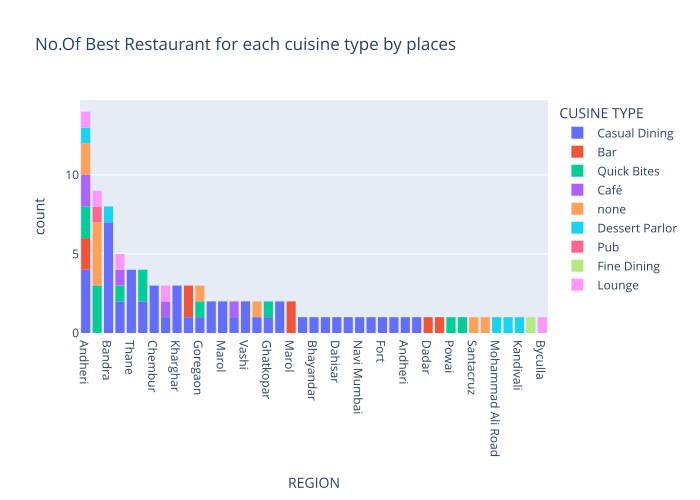

In [61]:
fig=px.histogram(highest_rated_df,x='REGION',color='CUSINE TYPE',
                title='No.Of Best Restaurant for each cuisine type by places').update_xaxes(categoryorder='total descending')
fig.show()

Q6) What is the AVG Price Distrubution of highest rated restaurant for each Cuisine Type in Mumbai?

In [65]:
highest_rated_price_df=highest_rated_df.groupby(by=['REGION','CUSINE TYPE'])['PRICE'].mean().reset_index()
highest_rated_price_df

,REGION,CUSINE TYPE,PRICE
0,Andheri,Casual Dining,1000.0
1,Andheri,Bar,1600.0
2,Andheri,Café,800.0
3,Andheri,Casual Dining,1212.5
4,Andheri,Dessert Parlor,300.0
...,...,...,...
58,Thane,Café,800.0
59,Thane,Casual Dining,1000.0
60,Thane,Lounge,1400.0
61,Vashi,Casual Dining,700.0


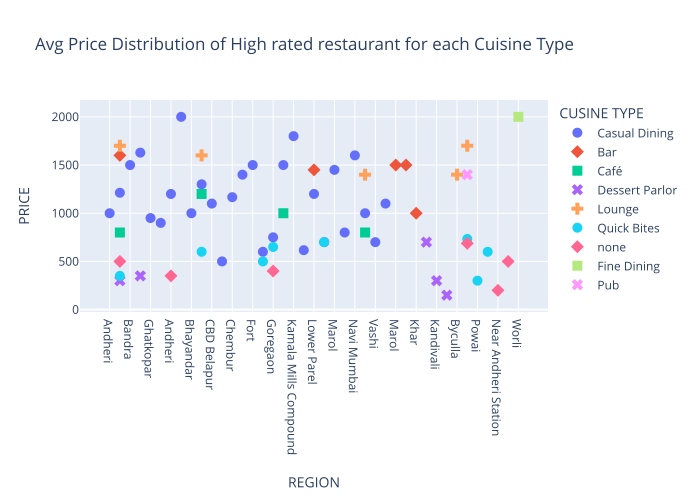

In [66]:
fig=px.scatter(highest_rated_price_df,x='REGION',y='PRICE',color='CUSINE TYPE',symbol='CUSINE TYPE',
              title='Avg Price Distribution of High rated restaurant for each Cuisine Type').update_traces(marker_size=10)
fig.show()

Q7) Which areas have a large number of Chinese Restaurant Market?

In [67]:
chinese_df=zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Chinese')]
chinese_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Lower Parel,Café,12noon to 1am,Very Good,4.2,2042,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15071,Lucknow Zaika,500,"North Indian,Chinese",Kurla,Quick Bites,12noon to 2am,Average,2.6,36,Mon-Sun
15072,Zuha's Kitchen,400,"Chinese,North Indian,Mughlai",Mumbai Central,Quick Bites,"12noon to 4pm,730pm to 430am",Average,3.3,13,Mon-Sun
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun


In [73]:
chinese_rest_df=chinese_df.groupby(by='REGION').agg({'NAME':'count','PRICE':'mean'}).rename(columns={
    'NAME': 'COUNT OF RESTAURANTS',
    'PRICE': 'AVERAGE PRICE'
}).reset_index()
chinese_rest_df=chinese_rest_df.sort_values('COUNT OF RESTAURANTS',ascending=False).head(25)
chinese_rest_df.head()

,REGION,COUNT OF RESTAURANTS,AVERAGE PRICE
36,Thane,341,589.017595
96,Mira Road,220,545.681818
90,Malad,185,599.189189
71,Goregaon,160,540.937500
65,Dombivali,158,539.259494


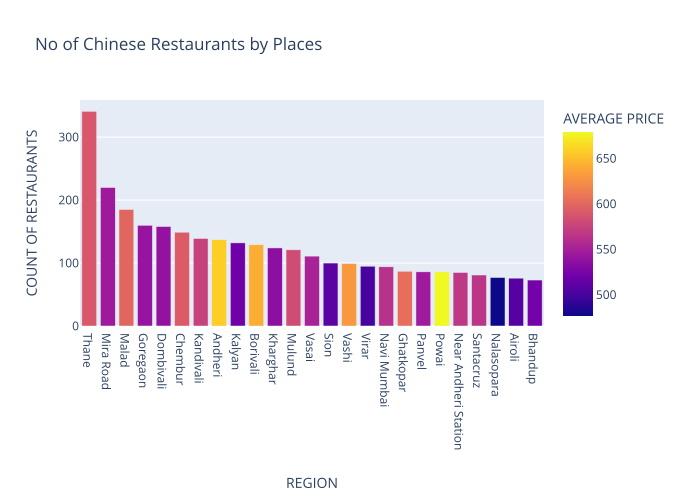

In [76]:
fig=px.bar(chinese_rest_df,x='REGION',y='COUNT OF RESTAURANTS',color='AVERAGE PRICE'
          ,title='No of Chinese Restaurants by Places')
fig.show()

Q8) Is there a realtion between Price and Rating by each Cuisine Type?


In [68]:
price_rating_df=zomato_df.groupby(['CUSINE TYPE','RATING'])['PRICE'].mean().reset_index()
price_rating_df

,CUSINE TYPE,RATING,PRICE
0,Bakery,2.7,400.000000
1,Bakery,2.8,285.714286
2,Bakery,2.9,328.571429
3,Bakery,3.0,300.000000
4,Bakery,3.1,369.117647
...,...,...,...
278,none,4.3,683.333333
279,none,4.4,555.000000
280,none,4.5,420.000000
281,none,4.6,687.500000


In [69]:
fig=px.line(price_rating_df,y='PRICE',x='RATING',color='CUSINE TYPE')
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Q9) Is  there a relation between region and Price?


In [72]:
region_price_df=zomato_df.groupby(['REGION'])['PRICE'].mean().reset_index()
region_price_df

,REGION,PRICE
0,Andheri,1250.000000
1,Andheri,590.049383
2,Bandra,1675.000000
3,Bandra,718.273381
4,Bhayandar,150.000000
...,...,...
131,Vikhroli,480.434783
132,Vile Parle,464.457831
133,Virar,452.027027
134,Wadala,427.500000


In [75]:
fig=px.scatter(region_price_df,x='REGION',y='PRICE').update_traces(marker_size=8)
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Q10) Find the list of Affordable restaurants?


The Criteria for Affordable Restaurants would be :-
1) Low Price
2) High Rated 

First Step will be to find the restaurants with average cost 1/4th the average cost of most expensive 
restaturants in our dataframe 

let me explain:- The most Expensive restaturants has an average meal cost = 6000. We will try to 
stay economical and only pick the restaturants that are 1/4th of 6000

In [76]:
max_price=zomato_df['PRICE'].max()
one_fourth_price=max_price/4
one_fourth_price

1250.0

In [77]:
#Finding list of restaurants that have price less than and equal to 1/4th of the max price 
# i.e finding cheap Restaturants 

aff_rest_df=zomato_df[['NAME','PRICE','CUSINE_CATEGORY','REGION','CUSINE TYPE']]
aff_rest_df=aff_rest_df[aff_rest_df['PRICE']<=1250]
aff_rest_df.sort_values(by='PRICE',inplace=True)
aff_rest_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
6137,Sanjog Wine N Dine,5,"North Indian,Chinese",Thane,Casual Dining
9598,Ho5 Store,50,Fast Food,Matunga,none
2925,Jab We Eat,50,"South Indian,North Indian,Maharashtrian,Fast Food",Girgaum,none
11239,Cakewaali.co,100,Bakery,Navi Mumbai,Bakery
6390,Kamath's Ice Cream,100,"Desserts,Ice Cream",Andheri,Dessert Parlor
...,...,...,...,...,...
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining
6941,90ML Bar & Kitchen,1200,"Continental,Asian,North Indian",Bandra,Casual Dining
6045,Fabelle at The Chocolate Boutique - ITC Grand ...,1250,Desserts,Parel,Dessert Parlor
7301,SamBar Pub & Kitchen,1250,"Finger Food,South Indian,North Indian",Khar,Pub


In [78]:
highrate_rest_df=zomato_df[['NAME','PRICE','CUSINE_CATEGORY','REGION','CUSINE TYPE','RATING']]
highrate_rest_df=highrate_rest_df[highrate_rest_df['RATING']>=4.5]
highrate_rest_df.sort_values(by='PRICE',inplace=True)
highrate_rest_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,RATING
1502,Cake Centre-The Dessert Maker,150,Desserts,Mohammad Ali Road,Dessert Parlor,4.6
807,Moussestruck,200,Desserts,Near Andheri Station,none,4.5
763,Curry And Combos Twist,200,"North Indian,Chinese",Andheri,Quick Bites,4.5
14234,Cone Culture,250,European,Kharghar,Casual Dining,4.6
725,Belo Pops,300,"Ice Cream,Desserts,Beverages",Andheri,none,4.5
...,...,...,...,...,...,...
8887,Drifters Tap Station,2000,"North Indian,Continental,European,American",Bandra,Casual Dining,4.5
1786,Global Fusion,2000,"Chinese,Japanese,Asian,North Indian",Worli,Fine Dining,4.6
5335,Mia Cucina,2000,Italian,Bandra,Casual Dining,4.5
12625,House of Mandarin,2100,"Chinese,Sushi,Asian",Bandra,Casual Dining,4.5


In [79]:
highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['NAME', 'REGION'])
highrate_aff_df = highrate_aff_df[['NAME', 'PRICE_x', 'CUSINE_CATEGORY_x', 'REGION', 'CUSINE TYPE_x']]
highrate_aff_df.rename(columns={'NAME':'NAME', 'PRICE_x':'PRICE', 'CUSINE_CATEGORY_x':'CUSINE_CATEGORY',
 'REGION':'REGION', 'CUSINE TYPE_x':'CUSINE TYPE'},inplace=True)

In [80]:
# Affordable Restaurants with low price and high rating
highrate_aff_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
0,Cake Centre-The Dessert Maker,150,Desserts,Mohammad Ali Road,Dessert Parlor
1,Curry And Combos Twist,200,"North Indian,Chinese",Andheri,Quick Bites
2,Moussestruck,200,Desserts,Near Andheri Station,none
3,Cone Culture,250,European,Kharghar,Casual Dining
4,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor
...,...,...,...,...,...
60,Invento,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Lower Parel,Casual Dining
61,Spice Republic,1200,"Cafe,Continental,Mediterranean,Mexican,Italian...",Borivali,Café
62,Culinary Tales,1200,"Chinese,European,Continental,Salad,Italian,Pizza",Andheri,Casual Dining
63,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Andheri,Casual Dining


Q11) Find the list of most Reliable Restaurants?